In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import  GridSearchCV
from sklearn.metrics import classification_report, confusion_matrix, roc_curve, auc
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.multiclass import OneVsRestClassifier

# Set plot style
plt.style.use('default')
sns.set_theme()

In [2]:
# Load data
train_data = pd.read_csv('archive/train.csv')
val_data = pd.read_csv('archive/validation.csv')
test_data = pd.read_csv('archive/test.csv')

In [3]:
# Select features
features = ['SchoolType', 'Locale', 'InternetAccess', 'SES_Quartile', 
           'ParentalEducation', 'Romantic', 'Extracurricular', 'ParentSupport']
target = 'Race'

In [4]:
le_dict = {}
X_train = pd.DataFrame()
X_val = pd.DataFrame()
X_test = pd.DataFrame()

for feature in features:
    le = LabelEncoder()
    le_dict[feature] = le
    X_train[feature] = le.fit_transform(train_data[feature])
    X_val[feature] = le.transform(val_data[feature])
    X_test[feature] = le.transform(test_data[feature])

In [5]:

le_target = LabelEncoder()
y_train = le_target.fit_transform(train_data[target])
y_val = le_target.transform(val_data[target])
y_test = le_target.transform(test_data[target])

# Scale features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val)
X_test_scaled = scaler.transform(X_test)

In [6]:
# Initialize and train model
model = OneVsRestClassifier(LogisticRegression(max_iter=1000, random_state=42))

# Hyperparameter tuning
param_grid = {
    'estimator__C': [0.1, 1, 10, 100],
    'estimator__penalty': ['l2'],
    'estimator__solver': ['liblinear']
}

grid_search = GridSearchCV(model, param_grid, cv=5, scoring='accuracy')
grid_search.fit(X_train_scaled, y_train)

# Get best model
best_model = grid_search.best_estimator_

# Make predictions
y_pred_train = best_model.predict(X_train_scaled)
y_pred_val = best_model.predict(X_val_scaled)
y_pred_test = best_model.predict(X_test_scaled)

# Get prediction probabilities
y_prob_train = best_model.predict_proba(X_train_scaled)
y_prob_val = best_model.predict_proba(X_val_scaled)
y_prob_test = best_model.predict_proba(X_test_scaled)

print("Best parameters:", grid_search.best_params_)

Best parameters: {'estimator__C': 0.1, 'estimator__penalty': 'l2', 'estimator__solver': 'liblinear'}



=== Evaluation on Training dataset ===

Classification Report:


c:\anaconda\anaconda3\envs\math\lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
c:\anaconda\anaconda3\envs\math\lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
c:\anaconda\anaconda3\envs\math\lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


              precision    recall  f1-score   support

       Asian       0.00      0.00      0.00    400754
       Black       0.00      0.00      0.00   1200976
    Hispanic       0.00      0.00      0.00   2319159
       Other       0.00      0.00      0.00    159372
 Two-or-more       0.00      0.00      0.00    400991
       White       0.44      1.00      0.61   3519522

    accuracy                           0.44   8000774
   macro avg       0.07      0.17      0.10   8000774
weighted avg       0.19      0.44      0.27   8000774



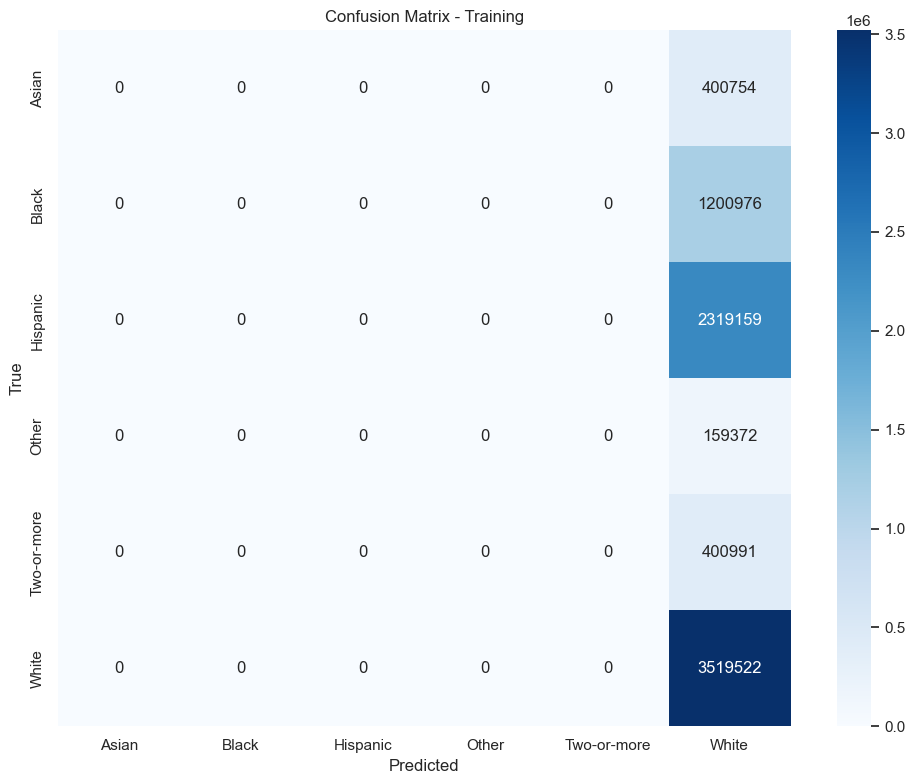


=== Evaluation on Validation dataset ===

Classification Report:


c:\anaconda\anaconda3\envs\math\lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
c:\anaconda\anaconda3\envs\math\lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
c:\anaconda\anaconda3\envs\math\lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


              precision    recall  f1-score   support

       Asian       0.00      0.00      0.00     49619
       Black       0.00      0.00      0.00    149375
    Hispanic       0.00      0.00      0.00    290697
       Other       0.00      0.00      0.00     19595
 Two-or-more       0.00      0.00      0.00     49982
       White       0.44      1.00      0.61    439961

    accuracy                           0.44    999229
   macro avg       0.07      0.17      0.10    999229
weighted avg       0.19      0.44      0.27    999229



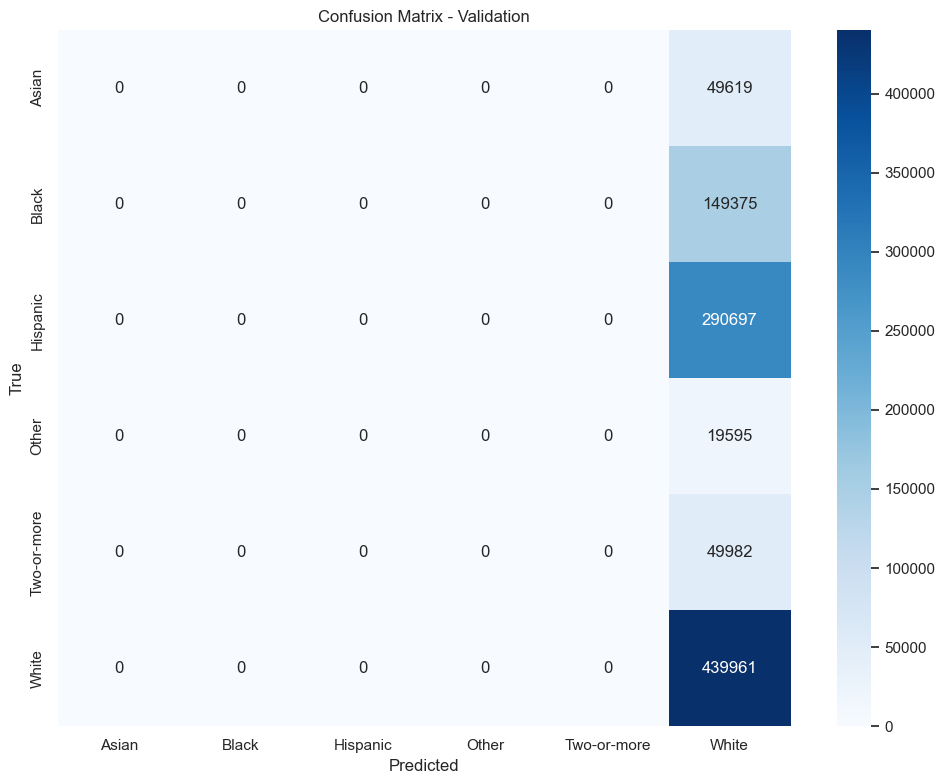


=== Evaluation on Test dataset ===

Classification Report:


c:\anaconda\anaconda3\envs\math\lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
c:\anaconda\anaconda3\envs\math\lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
c:\anaconda\anaconda3\envs\math\lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


              precision    recall  f1-score   support

       Asian       0.00      0.00      0.00     49933
       Black       0.00      0.00      0.00    149683
    Hispanic       0.00      0.00      0.00    290332
       Other       0.00      0.00      0.00     20256
 Two-or-more       0.00      0.00      0.00     50079
       White       0.44      1.00      0.61    439714

    accuracy                           0.44    999997
   macro avg       0.07      0.17      0.10    999997
weighted avg       0.19      0.44      0.27    999997



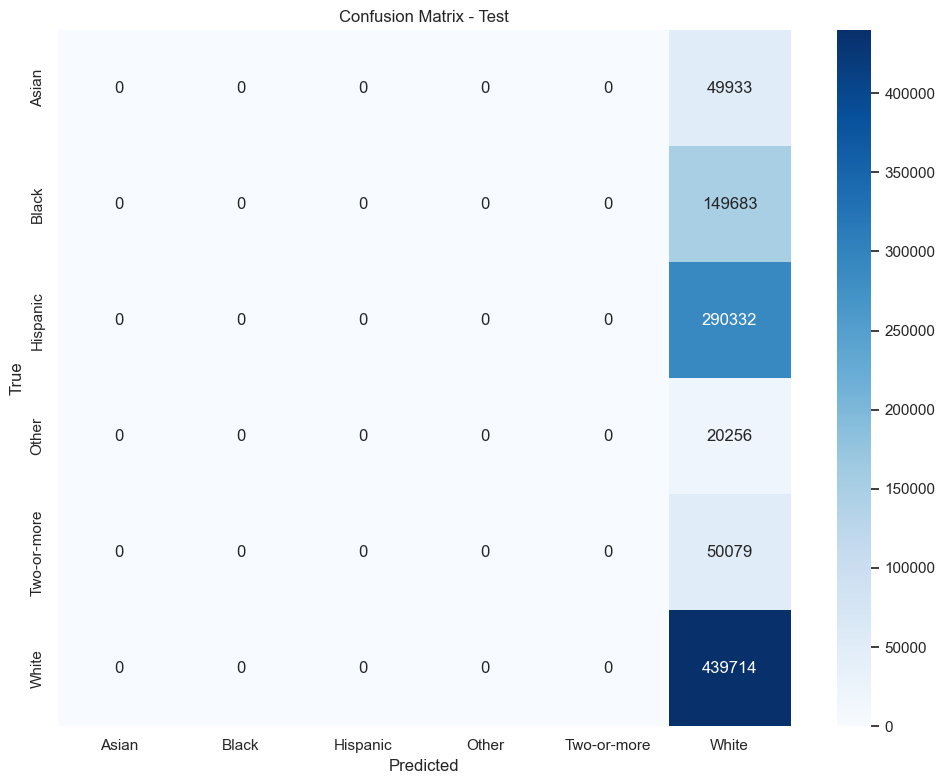

In [7]:
def evaluate_model(y_true, y_pred, y_prob, dataset_name):
    print(f"\n=== Evaluation on {dataset_name} dataset ===")
    print("\nClassification Report:")
    print(classification_report(y_true, y_pred, target_names=le_target.classes_))
    
    # Plot confusion matrix
    plt.figure(figsize=(10, 8))
    cm = confusion_matrix(y_true, y_pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=le_target.classes_,
                yticklabels=le_target.classes_)
    plt.title(f'Confusion Matrix - {dataset_name}')
    plt.xlabel('Predicted')
    plt.ylabel('True')
    plt.tight_layout()
    plt.show()

# Evaluate on all datasets
evaluate_model(y_train, y_pred_train, y_prob_train, "Training")
evaluate_model(y_val, y_pred_val, y_prob_val, "Validation")
evaluate_model(y_test, y_pred_test, y_prob_test, "Test")

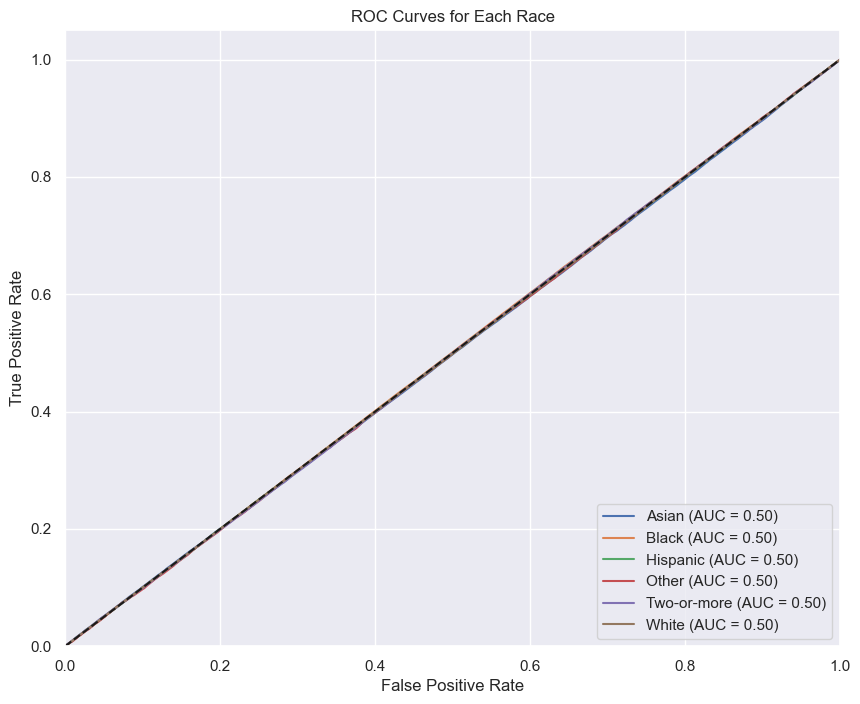

In [8]:
# Plot ROC curves for each class
plt.figure(figsize=(10, 8))
for i in range(len(le_target.classes_)):
    fpr, tpr, _ = roc_curve(y_test == i, y_prob_test[:, i])
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, label=f'{le_target.classes_[i]} (AUC = {roc_auc:.2f})')

plt.plot([0, 1], [0, 1], 'k--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curves for Each Race')
plt.legend(loc="lower right")
plt.show()

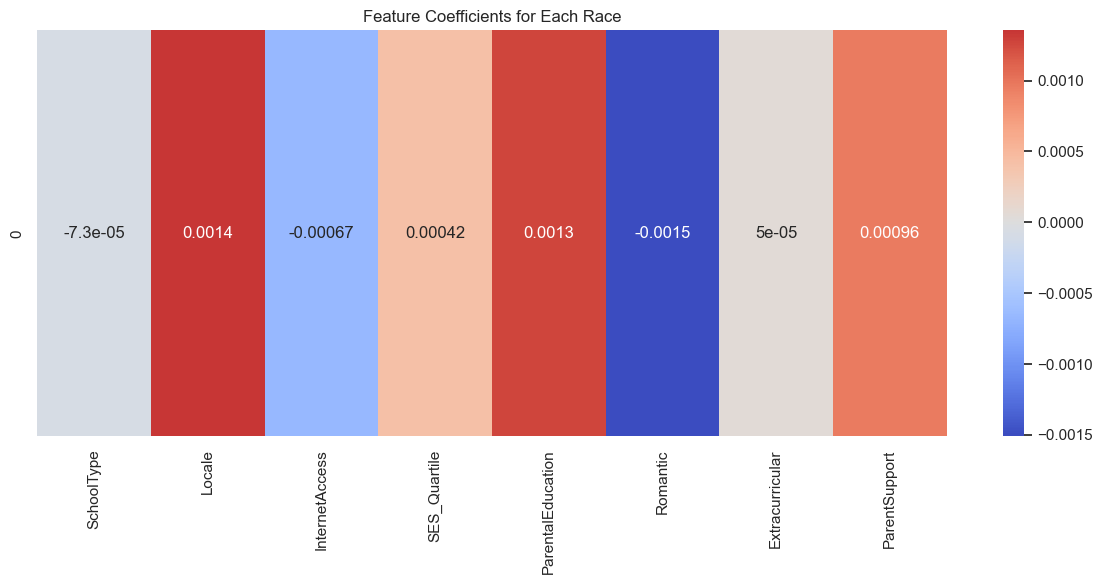

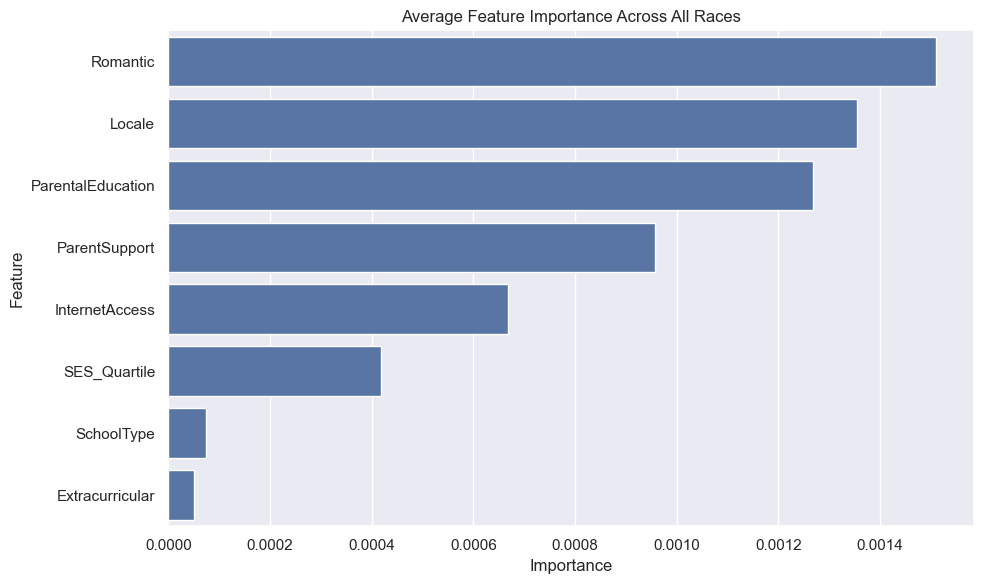

In [9]:
# Get coefficients for each class
coefficients = pd.DataFrame(
    best_model.estimators_[0].coef_,
    columns=features
)

# Plot coefficients
plt.figure(figsize=(12, 6))
sns.heatmap(coefficients, annot=True, cmap='coolwarm', center=0)
plt.title('Feature Coefficients for Each Race')
plt.tight_layout()
plt.show()

# Calculate feature importance
importance = pd.DataFrame({
    'Feature': features,
    'Importance': np.abs(coefficients).mean(axis=0)
})
importance = importance.sort_values('Importance', ascending=False)

# Plot feature importance
plt.figure(figsize=(10, 6))
sns.barplot(x='Importance', y='Feature', data=importance)
plt.title('Average Feature Importance Across All Races')
plt.tight_layout()
plt.show()

In [10]:
# Save results
results = {
    'model_params': grid_search.best_params_,
    'feature_importance': importance.to_dict('records'),
    'performance': {
        'train': classification_report(y_train, y_pred_train, output_dict=True),
        'validation': classification_report(y_val, y_pred_val, output_dict=True),
        'test': classification_report(y_test, y_pred_test, output_dict=True)
    }
}

# Save feature importance to CSV
importance.to_csv('feature_importance_race.csv', index=False)

# Print final summary
print("\n=== Final Analysis Results ===")
print("\nTop 5 Most Important Features:")
print(importance.head())

c:\anaconda\anaconda3\envs\math\lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
c:\anaconda\anaconda3\envs\math\lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
c:\anaconda\anaconda3\envs\math\lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
c:\anaconda\anacond


=== Final Analysis Results ===

Top 5 Most Important Features:
                             Feature  Importance
Romantic                    Romantic    0.001509
Locale                        Locale    0.001354
ParentalEducation  ParentalEducation    0.001269
ParentSupport          ParentSupport    0.000958
InternetAccess        InternetAccess    0.000668


c:\anaconda\anaconda3\envs\math\lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
